# The Curators - Phase 1: Baseline ResNet-50 Classifier
**CSC 487 - Winter 2026**  
**Goal:** Fine-tune a pretrained ResNet-50 to classify artwork as AI-generated or human-created.

In [1]:
!pip install torchvision scikit-learn

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score


## Step 1: Set Up Data Transforms
We resize to 224x224 (what ResNet-50 expects) and normalize using ImageNet stats.  
Training data also gets random flips, rotations, and color jitter for data augmentation.

In [3]:
# transform the data for phase 1, and randomly alter images so that model sees variety (augmentation)
trainTransform = transforms.Compose([

    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    transforms.ToTensor(),

    # normalize using ImageNet mean and std
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# transform for validation and test data w/ no augmentation essentially like not using fit
valTestTransform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("transforms defined!")

transforms defined!


## Step 2: Load the Dataset and Split It
We load the full dataset, then split into 70% train / 15% val / 15% test using stratified sampling so both classes stay proportional in each split.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/humanVSaiART/Art"

fullDataset = datasets.ImageFolder(DATA_PATH)

# get all the labels (0 = AiArtData, 1 = RealArt) so we can do stratified splits
allLabels = [label for _, label in fullDataset.samples]

# class names so we know which index is which
print("class names:", fullDataset.classes)
print("total images:", len(fullDataset))
print("label 0 count:", allLabels.count(0))
print("label 1 count:", allLabels.count(1))

Mounted at /content/drive
class names: ['AiArtData', 'RealArt']
total images: 973
label 0 count: 539
label 1 count: 434


In [5]:
# create index arrays so we can split the dataset
allIndices = list(range(len(fullDataset)))

# first split off the 15% test set and we use stratify to keep class balance bc of the imblance in images
trainValIndices, testIndices = train_test_split(
    allIndices,
    test_size=0.15,
    random_state=42,
    stratify=allLabels
)

# get labels for just the train+val portion so we can stratify again
trainValLabels = [allLabels[i] for i in trainValIndices]

# now split train+val into 70% train and 15% val
# 15 / 85 = 0.176 so test_size here should be 0.176 for correct balanced proportions
trainIndices, valIndices = train_test_split(
    trainValIndices,
    test_size=0.176,
    random_state=42,
    stratify=trainValLabels
)

print("train size:", len(trainIndices))
print("val size:  ", len(valIndices))
print("test size: ", len(testIndices))

train size: 681
val size:   146
test size:  146


In [6]:

fullDatasetTrain = datasets.ImageFolder(DATA_PATH, transform=trainTransform)

fullDatasetValTest = datasets.ImageFolder(DATA_PATH, transform=valTestTransform)

# subset is like [:] so we can access dataset by index list
trainSet = Subset(fullDatasetTrain,   trainIndices)
valSet   = Subset(fullDatasetValTest, valIndices)
testSet  = Subset(fullDatasetValTest, testIndices)


In [7]:
BATCH_SIZE = 32

trainLoader = DataLoader(trainSet, batch_size=BATCH_SIZE, shuffle=True)

valLoader  = DataLoader(valSet,  batch_size=BATCH_SIZE, shuffle=False)
testLoader = DataLoader(testSet, batch_size=BATCH_SIZE, shuffle=False)

print("train batches:", len(trainLoader))
print("val batches:  ", len(valLoader))
print("test batches: ", len(testLoader))

train batches: 22
val batches:   5
test batches:  5


## Step 3: Build the Model
We load ResNet-50 pretrained on ImageNet, then replace the final layer with a new 2-class output layer. Everything else stays frozen at first so we dont destroy the pretrained weights.

In [8]:
# weights=IMAGENET1K_V1 = we want the weights trained on ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# freeze all the layers - we dont want to change the pretrained weights yet
for param in model.parameters():
    param.requires_grad = False

# replace the final fully connected layer with a new one that outputs 2 classes
numInputFeatures = model.fc.in_features
print("original fc input features:", numInputFeatures)

# replace with a simple linear layer for binary classification
# 2 outputs = AI art (0) or Human art (1)
model.fc = nn.Linear(numInputFeatures, 2)

# the new fc layer's parameters are unfrozen by default so only it will train
print("replaced final layer with 2-class output")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("using device:", device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 56.2MB/s]


original fc input features: 2048
replaced final layer with 2-class output
using device: cuda


## Step 4: Define Loss, Optimizer, and Helper Functions

In [9]:

lossFunction = nn.CrossEntropyLoss()

# filter(lambda p: p.requires_grad ...) gets only the trainable parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)



In [10]:

def getAccuracy(model, loader, device):

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total   += labels.size(0)

    return correct / total

## Step 5: Train the Model
We run the training loop for a set number of epochs. Each epoch the model sees the whole training set once.

In [11]:
NUM_EPOCHS = 10

# lists to keep track of metrics each epoch
trainAccuracyHistory = []
valAccuracyHistory   = []
trainLossHistory     = []

for epoch in range(NUM_EPOCHS):

    model.train()
    totalLoss = 0.0

    for images, labels in trainLoader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = lossFunction(outputs, labels)
        loss.backward()
        optimizer.step()

        totalLoss += loss.item()

    trainAcc = getAccuracy(model, trainLoader, device)
    valAcc   = getAccuracy(model, valLoader,   device)
    avgLoss  = totalLoss / len(trainLoader)

    trainAccuracyHistory.append(trainAcc)
    valAccuracyHistory.append(valAcc)
    trainLossHistory.append(avgLoss)

    print(f"epoch: {epoch+1:2d}/{NUM_EPOCHS}  loss: {avgLoss:.4f}  train acc: {trainAcc:.4f}  val acc: {valAcc:.4f}")

print("\ntraining done!")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch:  1/10  loss: 0.7108  train acc: 0.5771  val acc: 0.5685
epoch:  2/10  loss: 0.5875  train acc: 0.7504  val acc: 0.7808
epoch:  3/10  loss: 0.5244  train acc: 0.7709  val acc: 0.7808
epoch:  4/10  loss: 0.5127  train acc: 0.7930  val acc: 0.8014
epoch:  5/10  loss: 0.5102  train acc: 0.8076  val acc: 0.8082
epoch:  6/10  loss: 0.6098  train acc: 0.6902  val acc: 0.7192
epoch:  7/10  loss: 0.5412  train acc: 0.8032  val acc: 0.7945
epoch:  8/10  loss: 0.4834  train acc: 0.7988  val acc: 0.7808
epoch:  9/10  loss: 0.4611  train acc: 0.8062  val acc: 0.7603
epoch: 10/10  loss: 0.4434  train acc: 0.7797  val acc: 0.8014

training done!


## Step 6: Plot Training Curves

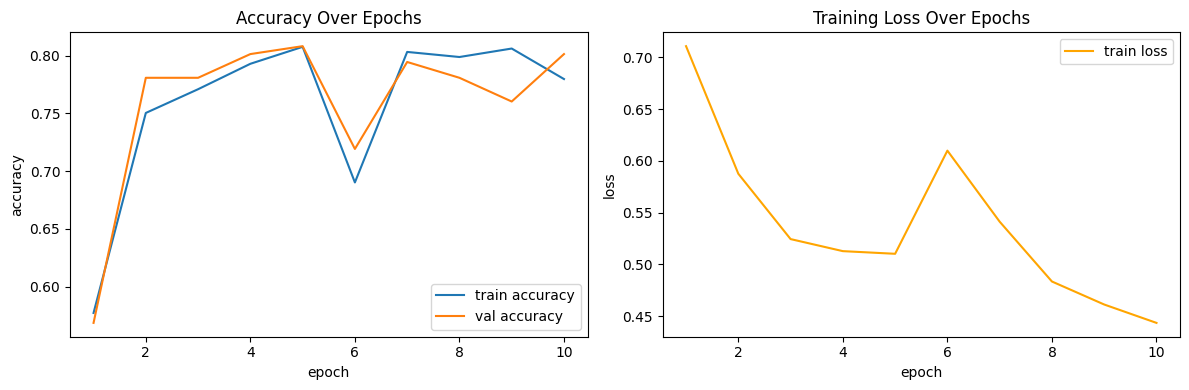

saved training_curves.png


In [12]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

# left plot - accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, trainAccuracyHistory, label="train accuracy")
plt.plot(epochs, valAccuracyHistory,   label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

# right plot - loss
plt.subplot(1, 2, 2)
plt.plot(epochs, trainLossHistory, label="train loss", color="orange")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("saved training_curves.png")

## Step 7: Evaluate on the Test Set
Now we run the model on the held-out test set and compute all our metrics: accuracy, precision, recall, F1, and AUC.

In [13]:
model.eval()

allTrueLabels  = []
allPredictions = []
# probabilities for AUC
allProbabilities = []

with torch.no_grad():

    for images, labels in testLoader:

        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        probabilitiess = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        allTrueLabels.extend(labels.cpu().numpy())
        allPredictions.extend(predictions.cpu().numpy())

        # save the probability of class 1 (human art) for AUC
        allProbabilities.extend(probabilitiess[:, 1].cpu().numpy())

# compute all the metrics
testAccuracy  = accuracy_score(allTrueLabels, allPredictions)
testPrecision = precision_score(allTrueLabels, allPredictions)
testRecall    = recall_score(allTrueLabels, allPredictions)
testF1        = f1_score(allTrueLabels, allPredictions)
testAUC       = roc_auc_score(allTrueLabels, allProbabilities)

print("=== TEST SET RESULTS ===")
print(f"Accuracy:  {testAccuracy:.4f}")
print(f"Precision: {testPrecision:.4f}")
print(f"Recall:    {testRecall:.4f}")
print(f"F1 Score:  {testF1:.4f}")
print(f"AUC:       {testAUC:.4f}")

=== TEST SET RESULTS ===
Accuracy:  0.6986
Precision: 0.6061
Recall:    0.9231
F1 Score:  0.7317
AUC:       0.8783


## Step 8: Confusion Matrix

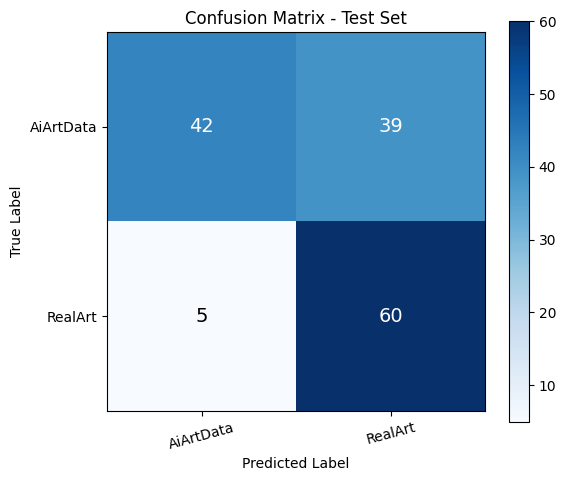

saved confusion_matrix.png


In [14]:
# rows = true labels, columns = predicted labels
cm = confusion_matrix(allTrueLabels, allPredictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

# label the axes with class names
classNames = fullDataset.classes
plt.xticks([0, 1], classNames, rotation=15)
plt.yticks([0, 1], classNames)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

# print the numbers inside each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black",
                 fontsize=14)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("saved confusion_matrix.png")

## Step 9: Save the Model
Save the trained weights so we can load them later for Phase 2 without retraining.

In [15]:
# save just the model weights (state_dict) - this is the standard way to save in pytorch
torch.save(model.state_dict(), "phase1_resnet50_weights.pth")
print("model saved to phase1_resnet50_weights.pth")

# to load it later you would do:
# model = models.resnet50()
# model.fc = nn.Linear(model.fc.in_features, 2)
# model.load_state_dict(torch.load("phase1_resnet50_weights.pth"))

model saved to phase1_resnet50_weights.pth
